In [1]:
import pandas as pd
from pathlib import Path

# Load Training Data

In [2]:
# load training data
DATA_DIR = "split_data"           # same folder frozen_train.ipynb reads from
SPLIT_DIR = "frozen-split_data"   # where frozen_train.ipynb wrote the split map
OUTPUT_DIR = Path("task3_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

contracts = pd.read_parquet(f"{DATA_DIR}/contracts.parquet")
documents = pd.read_parquet(f"{DATA_DIR}/documents.parquet")
categories = pd.read_parquet(f"{DATA_DIR}/categories.parquet")
annotation_sets = pd.read_parquet(f"{DATA_DIR}/annotation_sets.parquet")
spans = pd.read_parquet(f"{DATA_DIR}/spans.parquet")
split_map = pd.read_parquet(f"{SPLIT_DIR}/frozen-split.parquet")

documents = documents.merge(split_map, on="context_group_id", how="left")

# each document should have a split label
unmatched = documents["split"].isna().sum()
print(f"documents with NO split label (should be 0): {unmatched}")

train_documents = documents[documents["split"] == "train"].copy()
train_contract_ids = set(train_documents["contract_id"])

train_contracts = contracts[contracts["contract_id"].isin(train_contract_ids)].copy()
train_annotation_sets = annotation_sets[annotation_sets["contract_id"].isin(train_contract_ids)].copy()
train_spans = spans[spans["annotation_set_id"].isin(train_annotation_sets["annotation_set_id"])].copy()

print(f"train contracts:{len(train_contracts)}")
print(f"train documents:{len(train_documents)}")
print(f"train annotation sets:{len(train_annotation_sets)}")
print(f"train spans:{len(train_spans)}")

# rename references
contracts = train_contracts
documents = train_documents
categories = categories
annotation_sets = train_annotation_sets
spans = train_spans
# TODO: save all this in a parquet

documents with NO split label (should be 0): 0
train contracts:325
train documents:325
train annotation sets:13325
train spans:8964


# Finding Positive Examples
Using training data only, report the number of positive Contracts, distinct context groups, and annotated spans for each category.

In [3]:
# category names from task 5... TODO: verify these categories
final_cat_names = [
    "Governing Law",
    "Renewal Term",
    "Revenue/Profit Sharing",
    "Cap On Liability",
    "Uncapped Liability",
    "Termination For Convenience",
    "Anti-Assignment",
    "Audit Rights",
    "License Grant",
    "Exclusivity"
]
final_ids = categories.loc[categories.category_name.isin(final_cat_names), 'category_id']

# find the annotated sets that are related to each of the final categories
condition = annotation_sets.category_id.isin(final_ids) & ~annotation_sets.is_impossible
positive_sets = annotation_sets[condition]
positive_sets

,annotation_set_id,contract_id,category_id,is_impossible
3,contract_0001__anti_assignment,contract_0001,anti_assignment,False
11,contract_0001__exclusivity,contract_0001,exclusivity,False
13,contract_0001__governing_law,contract_0001,governing_law,False
18,contract_0001__license_grant,contract_0001,license_grant,False
31,contract_0001__renewal_term,contract_0001,renewal_term,False
...,...,...,...,...
16691,contract_0408__audit_rights,contract_0408,audit_rights,False
16698,contract_0408__exclusivity,contract_0408,exclusivity,False
16700,contract_0408__governing_law,contract_0408,governing_law,False
16705,contract_0408__license_grant,contract_0408,license_grant,False


In [4]:
# contracts that contain the positive sets
positive_contracts = positive_sets.merge(documents[['document_id','contract_id', 'context_group_id']], on="contract_id")

summary = positive_contracts.groupby('category_id').agg(
    num_positive_contracts=('contract_id', 'nunique'),
    num_positive_context_groups=('context_group_id', 'nunique'),
)

# num annotated spans for each category
positive_spans = spans.merge(positive_sets[["annotation_set_id", "category_id"]], on="annotation_set_id")
span_count = positive_spans.groupby('category_id').size().reset_index(name="num_positive_span")

summary = summary.merge(span_count, on="category_id")

**Final Summary**
The number of positive contracts, distinct context groups, and annotated spans for each category

In [5]:
summary

,category_id,num_positive_contracts,num_positive_context_groups,num_positive_span
0,anti_assignment,235,235,408
1,audit_rights,139,139,417
2,cap_on_liability,184,184,458
3,exclusivity,117,117,274
4,governing_law,274,273,290
5,license_grant,163,163,530
6,renewal_term,120,120,144
7,revenue_profit_sharing,103,103,269
8,termination_for_convenience,123,122,165
9,uncapped_liability,78,78,123


 Confirm that each category has at least 20 positive Contracts and 20 positive context groups. Document and justify any exception.

Each category has sufficient examples of positive contracts and context groups.

In [6]:
(summary["num_positive_contracts"] < 20).any() | (summary["num_positive_context_groups"] < 20).any()

np.False_

# Category Co-Occurrence
Show how often related categories appear together.

In [7]:
presence = positive_contracts[["contract_id", "category_id"]].drop_duplicates()
# contract x category 0/1 matrix, keeping all 41 category columns even if some have zero train support
presence_matrix = (
    presence.assign(present=1)
    .pivot_table(index="contract_id", columns="category_id", values="present", fill_value=0)
    .reindex(columns=final_ids, fill_value=0)
)

# cooccurrence[i, j] = number of contracts where category i AND category j both appear
cooccurrence = presence_matrix.T.dot(presence_matrix)
cooccurrence

category_id,renewal_term,governing_law,exclusivity,termination_for_convenience,anti_assignment,revenue_profit_sharing,license_grant,audit_rights,uncapped_liability,cap_on_liability
category_id,,,,,,,,,,
renewal_term,120.0,114.0,60.0,52.0,107.0,55.0,77.0,75.0,42.0,91.0
governing_law,114.0,274.0,113.0,117.0,229.0,94.0,155.0,137.0,77.0,180.0
exclusivity,60.0,113.0,117.0,40.0,102.0,58.0,91.0,70.0,38.0,83.0
termination_for_convenience,52.0,117.0,40.0,123.0,104.0,40.0,68.0,67.0,33.0,90.0
anti_assignment,107.0,229.0,102.0,104.0,235.0,81.0,146.0,129.0,77.0,164.0
revenue_profit_sharing,55.0,94.0,58.0,40.0,81.0,103.0,72.0,67.0,28.0,70.0
license_grant,77.0,155.0,91.0,68.0,146.0,72.0,163.0,94.0,64.0,124.0
audit_rights,75.0,137.0,70.0,67.0,129.0,67.0,94.0,139.0,55.0,113.0
uncapped_liability,42.0,77.0,38.0,33.0,77.0,28.0,64.0,55.0,78.0,78.0


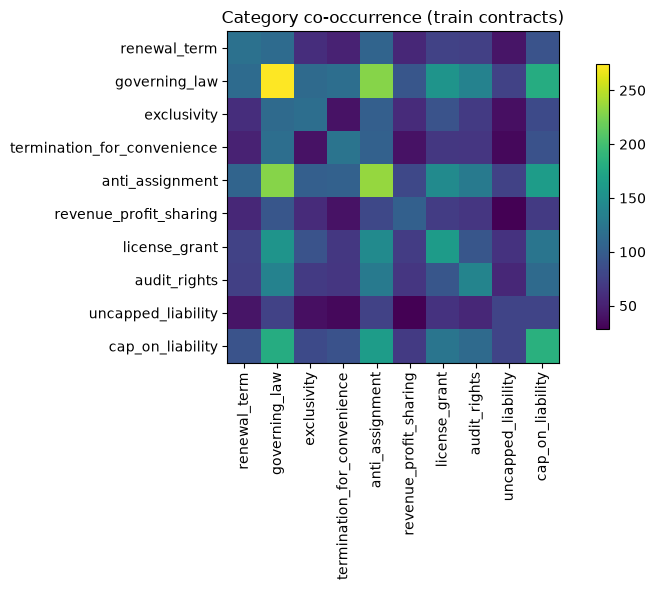

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(cooccurrence.values, cmap="viridis")
ax.set_xticks(range(len(cooccurrence.columns)))
ax.set_xticklabels(cooccurrence.columns, rotation=90, fontsize=10)
ax.set_yticks(range(len(cooccurrence.index)))
ax.set_yticklabels(cooccurrence.index, fontsize=10)
ax.set_title("Category co-occurrence (train contracts)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Hard Examples
 Provide five representative positive source-text excerpts and five realistic hard-negative source-text excerpts from the training Contracts for each category. For every excerpt, record its source Contract and text location. For each positive excerpt, also identify the annotated Span.

## Positive Examples

In [17]:
pos_span_w_contract = positive_spans.merge(
    positive_sets[['annotation_set_id', 'contract_id']],
    on='annotation_set_id'
)

# 5 random examples per group, seeded so "randomness" persists
positive_examples = pos_span_w_contract[["contract_id", "annotation_set_id", "category_id", "answer_text", "answer_start", "answer_end"]].groupby("category_id").sample(n=5, random_state=42)

positive_examples

,contract_id,annotation_set_id,category_id,answer_text,answer_start,answer_end
506,contract_0073,contract_0073__anti_assignment,anti_assignment,Consequently either this Agreement or any of t...,87997,88434
1675,contract_0214,contract_0214__anti_assignment,anti_assignment,"Either Party may, without consent of the other...",243853,244338
1947,contract_0249,contract_0249__anti_assignment,anti_assignment,Neither this Agreement nor any rights or oblig...,85146,85673
269,contract_0042,contract_0042__anti_assignment,anti_assignment,This Agreement may not be assigned by Broker D...,25119,25275
336,contract_0056,contract_0056__anti_assignment,anti_assignment,"The Distributor shall not sub-license, transfe...",12823,12960
1295,contract_0177,contract_0177__audit_rights,audit_rights,The Auditing Party may cause the Auditor to pe...,50688,51060
940,contract_0137,contract_0137__audit_rights,audit_rights,Franchisee shall fully cooperate with Pretzel ...,147028,147187
2724,contract_0356,contract_0356__audit_rights,audit_rights,"Premier, shall have the right, directly or thr...",16698,17052
2440,contract_0318,contract_0318__audit_rights,audit_rights,"SHPS shall have the right, upon reasonable pri...",6856,7078
1121,contract_0160,contract_0160__audit_rights,audit_rights,In addition to any inspection rights granted u...,44670,44887


In [21]:
display_samples = positive_examples.sample(n=5, random_state=42)
for _, sample in display_samples.iterrows():
    print(f"CATEGORY ID: {sample['category_id']}")
    print(f"CONTRACT ID: {sample['contract_id']}")
    print(f"EXAMPLE: {sample['answer_text']}\n")

CATEGORY ID: cap_on_liability
CONTRACT ID: contract_0208
EXAMPLE: IBM will give Customer a credit equal to the amount Customer paid IBM for the applicable Materials or for use of the applicable Base Components up to a maximum of twelve (12) months of applicable charges.

CATEGORY ID: revenue_profit_sharing
CONTRACT ID: contract_0360
EXAMPLE: In consideration of the license of Liquidmetal Technical Information and the Licensed Equipment granted by Liquidmetal, Eutectix agrees to pay Liquidmetal a cash royalty based on a percentage of the invoice price of any Licensed Products (but not including Liquidmetal Products) sold by Eutectix or its permitted sublicensees and for which payment was actually received by Eutectix.

CATEGORY ID: renewal_term
CONTRACT ID: contract_0167
EXAMPLE: Within ninety (90) days of our receipt of your notice to renew, we will furnish you with written notice of:  (i) reasons which could cause us not to grant a renewal to you including but not limited to any defic

## Negative Examples

In [ ]:
# find the annotated sets that are related to each of the final categories
condition = annotation_sets.category_id.isin(final_ids) & annotation_sets.is_impossible
negative_sets = annotation_sets[condition]
negative_sets

In [35]:
all_spans_w_category = spans.merge(annotation_sets[["annotation_set_id", "category_id", "contract_id"]], on="annotation_set_id")
negative_spans = all_spans_w_category[~all_spans_w_category['span_id'].isin(positive_spans['span_id'])]

,span_id,annotation_set_id,source_qa_id,answer_text,answer_start,answer_end,category_id,contract_id
0,contract_0001__document_name__span_000,contract_0001__document_name,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,DISTRIBUTOR AGREEMENT,44,65,document_name,contract_0001
1,contract_0001__parties__span_000,contract_0001__parties,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Distributor,244,255,parties,contract_0001
2,contract_0001__parties__span_001,contract_0001__parties,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Electric City of Illinois L.L.C.,49574,49606,parties,contract_0001
3,contract_0001__parties__span_002,contract_0001__parties,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Electric City of Illinois LLC,212,241,parties,contract_0001
4,contract_0001__parties__span_003,contract_0001__parties,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Company,197,204,parties,contract_0001
...,...,...,...,...,...,...,...,...
8957,contract_0408__volume_restriction__span_003,contract_0408__volume_restriction,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Should Company request for North to conduct Ad...,7104,7375,volume_restriction,contract_0408
8959,contract_0408__post_termination_services__span...,contract_0408__post_termination_services,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Said books and records shall be maintained for...,12067,12195,post_termination_services,contract_0408
8961,contract_0408__insurance__span_000,contract_0408__insurance,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,"Company agrees, at its own expense, to obtain ...",20750,21071,insurance,contract_0408
8962,contract_0408__insurance__span_001,contract_0408__insurance,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Such insurance policy shall be maintained wit...,21123,21228,insurance,contract_0408


Confirm that there are no duplicates (both positive and negative examples)

In [33]:
negative_spans.shape[0] + positive_spans.shape[0] == spans.shape[0]

True

In [37]:
# 5 random examples per group, seeded so "randomness" persists
negative_examples = negative_spans[["contract_id", "annotation_set_id", "category_id", "answer_text", "answer_start", "answer_end"]].groupby("category_id").sample(n=5, random_state=42)
negative_examples

,contract_id,annotation_set_id,category_id,answer_text,answer_start,answer_end
241,contract_0011,contract_0011__affiliate_license_licensee,affiliate_license_licensee,Subject to the terms and conditions of this Ag...,18678,19342
7011,contract_0317,contract_0317__affiliate_license_licensee,affiliate_license_licensee,Any rights or license granted under this Artic...,27829,28217
2076,contract_0099,contract_0099__affiliate_license_licensee,affiliate_license_licensee,The supply of the Miltenyi Products hereunder ...,22585,23532
237,contract_0011,contract_0011__affiliate_license_licensee,affiliate_license_licensee,"The licenses granted in Sections 4.01(a), (b) ...",26912,27409
3925,contract_0182,contract_0182__affiliate_license_licensee,affiliate_license_licensee,Distributor hereby grants Zogenix an irrevocab...,105454,105738
...,...,...,...,...,...,...
2977,contract_0142,contract_0142__warranty_duration,warranty_duration,Although Vendor intends to provide a six-month...,29202,29387
1190,contract_0058,contract_0058__warranty_duration,warranty_duration,E.piphany further warrants that its Maintenanc...,9507,9729
1661,contract_0077,contract_0077__warranty_duration,warranty_duration,"For each new Authorized Location, upon written...",5853,6197
790,contract_0038,contract_0038__warranty_duration,warranty_duration,"Upon Manufacturer's request, Subcontractor wil...",15838,16148
